# FLEXtopo Calibration and Validation


In [5]:
# General python

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime
from Weigfun import Weigfun
from plateau import plateau_func
import warnings
warnings.filterwarnings('ignore')
# import ewatercycle.forcing
# import ewatercycle.observation.grdc
# import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print
import shutil
import xarray as xr

## Landscape parameters

Each landscape (plateau, hillslope, wetland) has own parameters that need to be calibrated

### Parameter overview
| Unit | Par[0] | Par[1] | Par[2] | Par[3] | Par[4] | Par[5] |
|------|--------|--------|--------|--------|--------|--------|
| Plateau | Imax | Ce | Sumax | beta | Pmax | Kf |
| Hillslope | Imax | Ce | Sumax | beta | D | Kf |
| Wetland | Imax | Ce | Sumax | beta | Cmax | Kf |

Catchment-level: `ParCatchment = [Ks, T_lag]`

### Hillslope

In [6]:
def hillslope_func(timestep, Par, forcing, Fluxes, States):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	D = Par[4]
	Kf = Par[5]
	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']

	t_max = len(Prec)
	Si = States[:, 0]
	Su = States[:, 1]
	Sf = States[:, 2]

	Ei_dt = Fluxes[:, 0]
	Ea_dt = Fluxes[:, 1]
	Qf_dt = Fluxes[:, 2]
	Qus_dt = Fluxes[:, 3]

	dt = 1
	t = timestep

	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt

	# Interception Reservoir
	if P_dt > 0:
		Si[t] = Si[t] + P_dt
		Pe_dt = max(0, Si[t] - I_max)
		Si[t] = Si[t] - Pe_dt
		Ei_dt[t] = 0
	else:
		# Evaporation only when there is no rainfall
		Pe_dt = 0
		Ei_dt[t] = min(Ep_dt, Si[t])
		Si[t] = Si[t] - Ei_dt[t]

	if t < t_max - 1:
		Si[t + 1] = Si[t]

	# Unsaturated Reservoir
	if Pe_dt > 0:
		rho = (Su[t] / Su_max) ** beta
		Su[t] = Su[t] + (1 - rho) * Pe_dt
		Quf_dt = rho * Pe_dt
	else:
		Quf_dt = 0

	# Transpiration
	Ep_dt = max(0, Ep_dt - Ei_dt[t])
	Ea_dt[t] = Ep_dt * (Su[t] / (Su_max * Ce))
	Ea_dt[t] = min(Ea_dt[t], Su[t])
	Su[t] = Su[t] - Ea_dt[t]
	if t < t_max - 1:
		Su[t + 1] = Su[t]


	# Preferential Percolation
	Qus_dt[t] = D * Quf_dt


	# Fast Reservoir
	Sf[t] = Sf[t] + (1 - D) * Quf_dt
	Qf_dt[t] = dt * Kf * Sf[t]
	Sf[t] = Sf[t] - min(Qf_dt[t], Sf[t])
	if t < t_max - 1:
		Sf[t + 1] = Sf[t]

	# Save output
	States[:, 0] = Si
	States[:, 1] = Su
	States[:, 2] = Sf

	Fluxes[:, 0] = Ei_dt
	Fluxes[:, 1] = Ea_dt
	Fluxes[:, 2] = Qf_dt
	Fluxes[:, 3] = Qus_dt

	return (Fluxes, States)

### Wetlands

In [7]:
def wetland_func(timestep, Par, forcing, Fluxes, States, Ss, landscape_per):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	C_max = Par[4]
	Kf = Par[5]

	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']


	t_max = len(Prec)
	Si = States[:,0]
	Su = States[:,1]
	Sf = States[:,2]

	Ei_dt = Fluxes[:,0]
	Ea_dt = Fluxes[:,1]
	Qf_dt = Fluxes[:,2]

	dt = 1
	t = timestep

	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt

	# Interception Reservoir
	if P_dt > 0:
		Si[t] = Si[t] + P_dt
		Pe_dt = max(0, Si[t]-I_max)
		Si[t] = Si[t] - Pe_dt
		Ei_dt[t] = 0
	else:
	# Evaporation only when there is no rainfall
		Pe_dt = 0
		Ei_dt[t] = min(Ep_dt, Si[t])
		Si[t] = Si[t] - Ei_dt[t]

	if t < t_max - 1:
		Si[t+1] = Si[t]


	# Unsaturated Reservoir
	if Pe_dt > 0:
		rho = (Su[t]/Su_max) ** beta
		Su[t] = Su[t] + (1-rho) * Pe_dt
		Quf_dt = rho * Pe_dt
	else:
		Quf_dt = 0


	# Transpiration
	Ep_dt = max(0, Ep_dt-Ei_dt[t])
	Ea_dt[t] = Ep_dt * (Su[t]/(Su_max*Ce))
	Ea_dt[t] = min(Ea_dt[t], Su[t])
	Su[t] = Su[t] - Ea_dt[t]


	# Capillary rise
	Qr_dt = (1-Su[t]/Su_max) * C_max * dt
	Qr_dt = min(Qr_dt, Ss[t] /landscape_per) #check if the groundwater has enough water (note: you need to use the landscape percentage!!!)

	if ((Su[t] + Qr_dt) > Su_max):
		Qr_dt = Su_max - Su[t]


	Su[t] = Su[t] + Qr_dt
	Ss[t] = Ss[t] - Qr_dt * landscape_per

	if t < t_max - 1:
		Su[t+1] = Su[t]

	# Fast Reservoir
	Sf[t] = Sf[t] + Quf_dt
	Qf_dt[t] = dt * Kf * Sf[t]
	Sf[t] = Sf[t]- min(Qf_dt[t], Sf[t])
	if t < t_max-1:
		Sf[t+1] = Sf[t]


	# Save output
	States[:,0] = Si
	States[:,1] = Su
	States[:,2] = Sf

	Fluxes[:,0] = Ei_dt
	Fluxes[:,1] = Ea_dt
	Fluxes[:,2] = Qf_dt

	return(Fluxes, States, Ss)

### Plateau

In [8]:
def plateau_func(timestep, Par, forcing, Fluxes, States):
 
    I_max  = Par[0]
    Ce     = Par[1]
    Su_max = Par[2]
    beta   = Par[3]
    P_max  = Par[4]   # max percolation to slow reservoir
    Kf     = Par[5]
 
    Prec = forcing['Prec']
    Etp  = forcing['Etp']
 
    t_max = len(Prec)
    Si    = States[:, 0]
    Su    = States[:, 1]
    Sf    = States[:, 2]
 
    Ei_dt  = Fluxes[:, 0]
    Ea_dt  = Fluxes[:, 1]
    Qf_dt  = Fluxes[:, 2]
    Qus_dt = Fluxes[:, 3]
 
    dt    = 1
    t     = timestep
    P_dt  = Prec[t] * dt
    Ep_dt = Etp[t] * dt
 
    #Interception reservoir
    # Throughfall: precip that exceeds the available interception capacity
    Pe_dt    = max(0, P_dt - max(0, I_max - Si[t]))
    Ei_dt[t] = min(Ep_dt, Si[t] + P_dt - Pe_dt)
 
    if t < t_max - 1:
        Si_new = Si[t] + dt * (P_dt - Pe_dt - Ei_dt[t])
        # FIX: if Si would exceed I_max, route the overflow as additional throughfall
        if Si_new > I_max:
            Pe_dt  += Si_new - I_max
            Si[t+1] = I_max
        else:
            Si[t+1] = max(0, Si_new)
 
    Ep_remain = max(0, Ep_dt - Ei_dt[t])
 
    #Unsaturated reservoir
    Cr    = (Su[t] / Su_max) ** beta
    Pu_dt = (1 - Cr) * Pe_dt   # infiltration into Su
    Qu_dt = Cr * Pe_dt          # direct runoff to fast reservoir
 
    # Transpiration
    Ea_dt[t] = Ce * (Su[t] / Su_max) * Ep_remain
 
    if t < t_max - 1:
        Su_new    = Su[t] + dt * (Pu_dt - Ea_dt[t])
        # Percolation to slow reservoir capped at P_max and available storage
        Qus_dt[t] = min(P_max, max(0, Su_new))
        Su_new   -= Qus_dt[t]
        # FIX: if Su would go negative, route the deficit as additional fast runoff
        if Su_new < 0:
            Qu_dt  += abs(Su_new)
            Su[t+1] = 0
        else:
            Su[t+1] = Su_new
    else:
        Qus_dt[t] = min(P_max, max(0, Su[t]))
 
    #Fast reservoir
    # FIX: compute outflow from Sf[t] (not Sf[t+1]) to avoid forward-time error
    Qf_dt[t] = Kf * Sf[t]
    if t < t_max - 1:
        Sf_new = Sf[t] + dt * Qu_dt - dt * Qf_dt[t]
        # FIX: if Sf would go negative, reduce outflow to what is available
        if Sf_new < 0:
            Qf_dt[t] = Sf[t] + dt * Qu_dt
            Sf[t+1]  = 0
        else:
            Sf[t+1] = Sf_new
 
    States[:, 0] = Si;  States[:, 1] = Su;  States[:, 2] = Sf
    Fluxes[:, 0] = Ei_dt;  Fluxes[:, 1] = Ea_dt
    Fluxes[:, 2] = Qf_dt;  Fluxes[:, 3] = Qus_dt
 
    return Fluxes, States

### Flextopo model 

In [9]:
def FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscapes):

	# Parameters and constants
	T_lag = ParCatchment[1]
	Ks = ParCatchment[0]
	dt = 1
	t_max = len(forcing['Qo'])

	# Initialize states
	States_plateau = np.zeros((t_max,3))
	States_hillslope = np.zeros((t_max,3))
	States_wetland = np.zeros((t_max,3))
	Ss = np.zeros((t_max,1))

	# Initialize fluxes
	Fluxes_plateau = np.zeros((t_max,4))
	Fluxes_hillslope = np.zeros((t_max,4))
	Fluxes_wetland = np.zeros((t_max,3))
	Qs_dt = np.zeros(t_max)
	Q_tot_dt = np.zeros(t_max)

	# Loop over time
	for t in range(0,t_max):

		# Plateau
		Fluxes_plateau, States_plateau = plateau_func(t, ParPlateau, forcing, Fluxes_plateau, States_plateau)
		# Hillslope
		Fluxes_hillslope, States_hillslope = hillslope_func(t, ParHillslope, forcing, Fluxes_hillslope, States_hillslope)

		# Wetland
		Fluxes_wetland, States_wetland, Ss = wetland_func(t, ParWetland, forcing, Fluxes_wetland, States_wetland, Ss, landscapes[2])

		# Slow Reservoir
		'''UPDATE'''
		Ss[t] = Ss[t] + Fluxes_plateau[t, 3] * landscapes[0] + Fluxes_hillslope[t, 3] * landscapes[1]
		Qs_dt = dt * Ks * Ss[t]
		Ss[t] = Ss[t] - min(Qs_dt,Ss[t])
		if t < t_max - 1:
			Ss[t+1] = Ss[t]

		'''UPDATE'''
		Q_tot_dt[t] = Qs_dt + Fluxes_plateau[t,2] * landscapes[0] + Fluxes_hillslope[t,2] * landscapes[1] + Fluxes_wetland[t,2] * landscapes[2]

	# Offset Q
	weigths = Weigfun(T_lag)

	Qm = np.convolve(Q_tot_dt, weigths)
	Qm = Qm[0:t_max]

	return(Qm)

## Landscapes

In QGIS we made HAND (Height Above Nearest Drainage): separates wetlands (low-lying) from upland units and the slope which separates plateaus from steeper hillslopes.

In [10]:
DEM = np.genfromtxt('DEM_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
slope = np.genfromtxt('slope_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
hand = np.genfromtxt('HAND_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
basin = np.genfromtxt('basin_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)

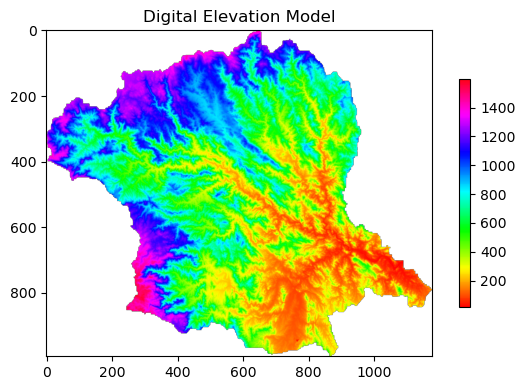

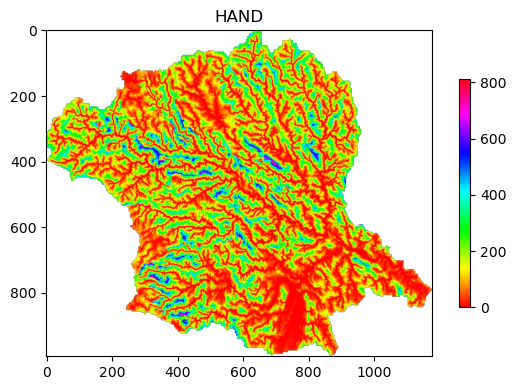

In [11]:
#plot DEM
fig, ax = plt.subplots(figsize=(6,4))
ax.set_title('Digital Elevation Model')
DEM[DEM==-9999] = np.nan
im = ax.imshow(DEM, cmap='hsv')
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

# plot HAND
fig, ax = plt.subplots(figsize=(6,4))
ax.set_title('HAND')
hand[hand==-9999] = np.nan
im = ax.imshow(hand, cmap='hsv')
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

## Classification
This is the classification we made:
| Class | Condition |
|-------|-----------|
| Wetland | HAND ≤ 5 m AND slope ≤ 9% |
| Plateau | HAND > 5 m AND slope ≤ 9% |
| Hillslope | slope > 9% |


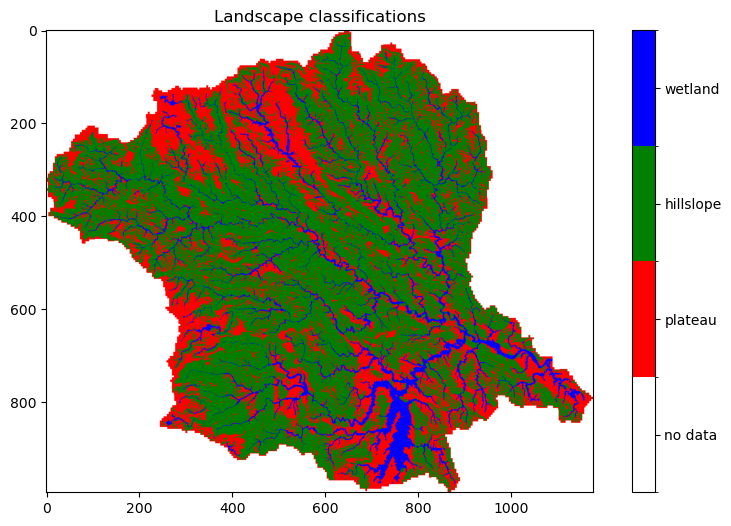

Hillslope percentage: 0.6040544567109684

Wetland percentage: 0.08657050074945284

Plateau percentage: 0.3092918540298783

In [12]:
'''UPDATE'''
# Make landscape classification
hillslope = np.array(slope) > 9
plateau = (np.array(hand) > 5) & (np.array(slope) <= 9)
wetland = (np.array(hand) <= 5) & (np.array(slope) <= 9)
basin = np.array(basin) > 0

'''UPDATE'''
hillslope_per = float(np.sum(hillslope))/float(np.sum(basin))
wetland_per = float(np.sum(wetland))/float(np.sum(basin))
plateau_per = float(np.sum(plateau))/float(np.sum(basin))

landscapes = np.zeros(DEM.shape)
landscapes[plateau] = 1
landscapes[hillslope] = 2
landscapes[wetland] = 3

# Plot landscapes
cmap = mpl.colors.ListedColormap(['white', 'red', 'green', 'blue'])
bounds = [0,1,2,3,4]
labels = ['no data', 'plateau', 'hillslope', 'wetland']
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, )

fig, ax = plt.subplots(figsize=(10,6))
ax.set_title('Landscape classifications')
im = ax.imshow(landscapes, cmap=cmap, norm=norm,)
# Create color bar
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5, 3.5])
cbar.set_ticklabels(labels)
plt.show()
landscape_per = np.array([plateau_per, hillslope_per, wetland_per])

print("Hillslope percentage:", hillslope_per)
print("Wetland percentage:", wetland_per)
print("Plateau percentage:", plateau_per)


## Loading forcing data 



In [ ]:
#shape area 
shape_area_manning = 6642 * 1e6  # m²

#evap
evap_daily = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily['Date'] = pd.to_datetime(evap_daily['system:index'], format='%Y%m%d')
evap_daily = evap_daily.set_index('Date')[['total_evaporation_sum']]
evap_daily = evap_daily.rename(columns={'total_evaporation_sum': 'ERA5_Evaporation'})
evap_daily['ERA5_Evaporation'] = evap_daily['ERA5_Evaporation'].abs() * 1000  # m/day → mm/day

#precip
precip_daily = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip_daily['Date'] = pd.to_datetime(precip_daily['system:index'], format='%Y%m%d')
precip_daily = precip_daily.set_index('Date')[['total_precipitation_sum']]
precip_daily = precip_daily.rename(columns={'total_precipitation_sum': 'ERA5_Precipitation'})
precip_daily['ERA5_Precipitation'] = precip_daily['ERA5_Precipitation'] * 1000  # m/day → mm/day

#discharge
Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=";",
    skiprows=36,
    header=0,
    encoding="cp1252",
    index_col=0,
    parse_dates=True,
)
Obs = Obs.rename(columns={" Value": "Q"})

# Remove  bad values 
Obs.loc[Obs['Q'] > 4000, 'Q'] = np.nan
Obs.loc[Obs['Q'] < 0, 'Q'] = np.nan   # <--- NEW

# m³/s → mm/day
Obs['Q'] = Obs['Q'] * 86400 / shape_area_manning * 1000



In [ ]:
# forcing and date range separation
data = (
    precip_daily[['ERA5_Precipitation']]
    .join(evap_daily[['ERA5_Evaporation']], how='inner')
    .join(Obs[['Q']], how='inner')
    .dropna()
)

data = data.rename(columns={
    'ERA5_Precipitation': 'Prec',
    'ERA5_Evaporation': 'Etp',
    'Q': 'Qo'
})

cal_start = "2014-01-01"
cal_end   = "2022-12-31"
val_start = "2023-01-01"
val_end   = "2024-12-31"
warmup_days = 365

cal_data = data.loc[cal_start:cal_end]
val_data = data.loc[val_start:val_end]
warmup_data = data.loc[(pd.to_datetime(cal_start) - pd.Timedelta(days=warmup_days)) : cal_start]

def make_forcing(df):
    return {
        'Prec': df['Prec'].values,
        'Etp': df['Etp'].values,
        'Qo':  df['Qo'].values
    }

forcing_warmup = make_forcing(warmup_data)
forcing_cal = make_forcing(cal_data)
forcing_val = make_forcing(val_data)
forcing_full = make_forcing(data)

[CAL] New best at run 0: NSE_cal = 0.067

[CAL] New best at run 7: NSE_cal = 0.214

[CAL] New best at run 11: NSE_cal = 0.453

[CAL] New best at run 19: NSE_cal = 0.485

[CAL] New best at run 33: NSE_cal = 0.566

...

Performance with calibration parameters:

NSE_cal = 0.6128086139126864

NSE_val = -0.9002842492684249

Final parameters after full-period optimization (theta_full):

Imax          4.177198
Ce            0.454746
beta          3.243346
Pmax          1.669832
Su_max_p    364.577038
Kf_p          0.712328
Su_max_h    114.361418
D_h           0.847168
Kf_h          0.956973
Su_max_w    328.653564
Cmax_w        3.347027
Kf_w          0.858502
Ks            0.973976
Tlag          4.129628
dtype: float64

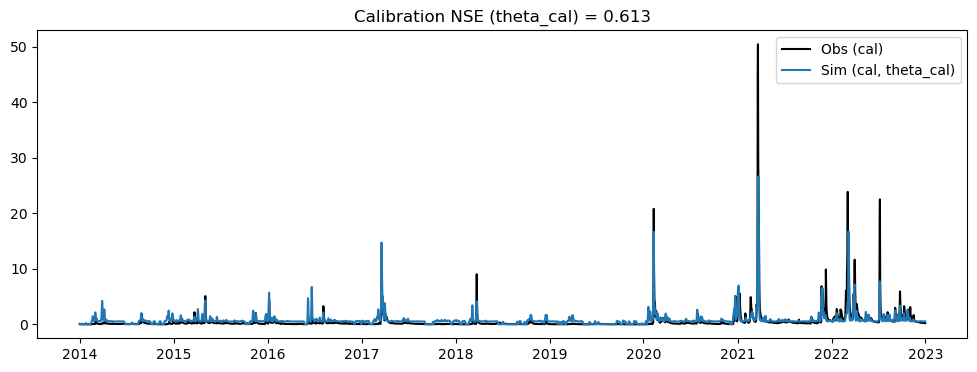

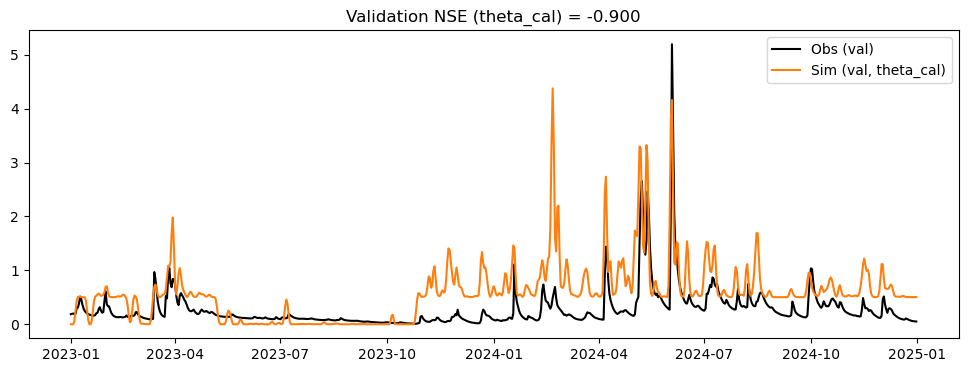

In [ ]:
# NSE
def nse(sim, obs):
    sim = np.maximum(sim, 0)  # remove negative simulated Q
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    return 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)


# different landscape

param_names = [
    "Imax", "Ce", "beta", "Pmax",        # shared
    "Su_max_p", "Kf_p",                  # plateau
    "Su_max_h", "D_h", "Kf_h",           # hillslope
    "Su_max_w", "Cmax_w", "Kf_w",        # wetland
    "Ks", "Tlag"                         # catchment
]

def run_flextopo_landscape(theta, forcing, landscape_per):
    Imax, Ce, beta, Pmax = theta[0:4]

    Su_max_p, Kf_p       = theta[4:6]
    Su_max_h, D_h, Kf_h  = theta[6:9]
    Su_max_w, Cmax_w, Kf_w = theta[9:12]

    Ks, Tlag             = theta[12:14]

    ParPlateau   = np.array([Imax, Ce, Su_max_p, beta, Pmax, Kf_p])
    ParHillslope = np.array([Imax, Ce, Su_max_h, beta, D_h, Kf_h])
    ParWetland   = np.array([Imax, Ce, Su_max_w, beta, Cmax_w, Kf_w])
    ParCatchment = np.array([Ks, Tlag])

    Qm = FLEXtopo(
        ParPlateau,
        ParHillslope,
        ParWetland,
        ParCatchment,
        forcing,
        landscape_per
    )

    return np.maximum(Qm, 0)


# parameters

param_bounds = np.array([
    (0, 5),      # Imax
    (0.1, 2),    # Ce
    (0.1, 5),    # beta
    (0, 5),      # Pmax

    (20, 400),   # Su_max_p
    (0.001, 1),  # Kf_p

    (20, 400),   # Su_max_h
    (0, 1),      # D_h
    (0.001, 1),  # Kf_h

    (20, 400),   # Su_max_w
    (0, 5),      # Cmax_w
    (0.001, 1),  # Kf_w

    (0.001, 1),  # Ks
    (0, 5),      # Tlag
])


# obj fun
def objective_cal(theta, landscape_per):
    _ = run_flextopo_landscape(theta, forcing_warmup, landscape_per)
    Qsim = run_flextopo_landscape(theta, forcing_cal, landscape_per)
    return -nse(Qsim, forcing_cal['Qo'])

def objective_full(theta, landscape_per):
    _ = run_flextopo_landscape(theta, forcing_warmup, landscape_per)
    Qsim = run_flextopo_landscape(theta, forcing_full, landscape_per)
    return -nse(Qsim, forcing_full['Qo'])


# sampl
def sample_theta(bounds):
    low = bounds[:, 0]
    high = bounds[:, 1]
    return low + (high - low) * np.random.rand(len(bounds))


# calibration
n_runs = 300
best_theta_cal = None
best_obj_cal = np.inf

for i in range(n_runs):
    theta = sample_theta(param_bounds)
    obj = objective_cal(theta, landscape_per)
    if obj < best_obj_cal:
        best_obj_cal = obj
        best_theta_cal = theta
        print(f"[CAL] New best at run {i}: NSE_cal = {-best_obj_cal:.3f}")

print("\nBest calibration parameters (theta_cal):")
print(pd.Series(best_theta_cal, index=param_names))


# validation
_ = run_flextopo_landscape(best_theta_cal, forcing_warmup, landscape_per)
Qcal = run_flextopo_landscape(best_theta_cal, forcing_cal, landscape_per)
Qval = run_flextopo_landscape(best_theta_cal, forcing_val, landscape_per)

NSE_cal = nse(Qcal, forcing_cal['Qo'])
NSE_val = nse(Qval, forcing_val['Qo'])

print("\nPerformance with calibration parameters:")
print("NSE_cal =", NSE_cal)
print("NSE_val =", NSE_val)


n_runs_full = 200
best_theta_full = best_theta_cal.copy()
best_obj_full = objective_full(best_theta_full, landscape_per)

for i in range(n_runs_full):
    theta = sample_theta(param_bounds)
    obj = objective_full(theta, landscape_per)
    if obj < best_obj_full:
        best_obj_full = obj
        best_theta_full = theta
        print(f"[FULL] New best at run {i}: NSE_full = {-best_obj_full:.3f}")

print("\nFinal parameters after full-period optimization (theta_full):")
print(pd.Series(best_theta_full, index=param_names))



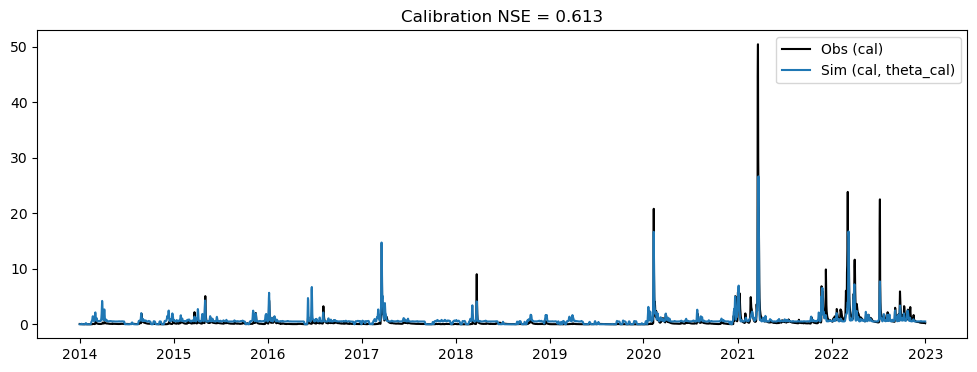

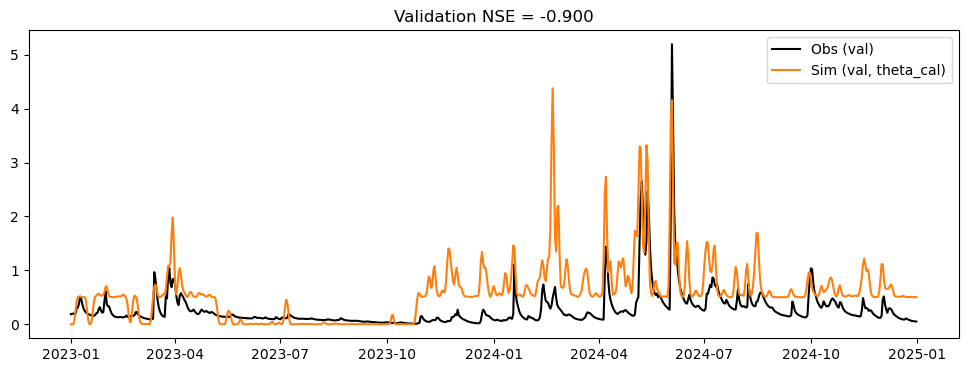

In [25]:
# plot
plt.figure(figsize=(12,4))
plt.plot(cal_data.index, forcing_cal['Qo'], label='Obs (cal)', color='k')
plt.plot(cal_data.index, Qcal, label='Sim (cal, theta_cal)', color='tab:blue')
plt.title(f'Calibration NSE = {NSE_cal:.3f}')
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(val_data.index, forcing_val['Qo'], label='Obs (val)', color='k')
plt.plot(val_data.index, Qval, label='Sim (val, theta_cal)', color='tab:orange')
plt.title(f'Validation NSE = {NSE_val:.3f}')
plt.legend()
plt.show()